# Age-Structured SEIHRV Model

Want to rewrite the existing SEIHRVD model, but using a class, `SEIHRVDsim`.

This then allows you to pass it in different parameters - depending on the age group (0-19, 20-64, 65+) - and produce the respective model. You can still vary vaccine time and efficacy, as well as lockdown duration just before you run the simulation. All other parameters are stored in the file `params.json` which is opened and split into `youngAgeGrp`, `adultAgeGrp`, `elderlyAgeGrp`. You then choose which to input as the first parameter when running the simulation.

The parameters that vary with age are:

- $d$ (probability of displaying symptoms)
- $h$ (probability of hospitalisation given symptomatic)
- $k$ (probability of death given hospitalisation)
- $compliance$ (value that lockdown divides transmission by)
- $N$ (population size)
- $S_0, E_0, I_0^S, I_0^A,$ (non-zero initial values (defined as 99.9%, 0.05%, 0.025%, 0.025% of $N$ respectively))

As expected, the three probabilities are all highest in the elderly, who are most at risk. $d$ and $k$ are lowest in the youngest group (ages 0 to 19), whereas $h$ is (just) lowest in the adult group.

The age groups (data from the ONS) are:

- **0 to 19 years:** $15,546,000$ people in the UK - 22.3% of population
- **20 to 64 years:** $40,668,000$ people in the UK - 58.4% of population
- **65+ years:** $13,415,000$ people in the UK - 19.3% of population




In [66]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import json
from types import SimpleNamespace

In [71]:
# Opening the params file and separating it into our three age categories

f = open("params.json", "r")
contents = f.read()
f.close()


params = json.loads(contents)

youngAgeGrp = params['0-19']
adultAgeGrp = params['20-64']
elderlyAgeGrp = params['65+']

In [68]:
class SEIHRVDsim:
    
    def __init__(self, ageGrpParams, vaccineStart, eta, lockdownStart, lockdownEnd):
        self.params = SimpleNamespace(**ageGrpParams)
        
        self.params.vaccineStart = vaccineStart
        self.params.eta = eta
        self.params.lockdownStart = lockdownStart
        self.params.lockdownEnd = lockdownEnd

        self.InitialVals = [self.params.S_U0, self.params.E_U0, self.params.I_SU0, self.params.I_AU0, self.params.H_U0, self.params.R_U0, self.params.D_U0, self.params.S_V0, self.params.S_VI0, self.params.E_V0, self.params.I_SV0, self.params.I_AV0, self.params.H_V0, self.params.R_V0, self.params.D_V0]
        
    def betaFunc(self,time):
        if self.params.lockdownStart < time <= self.params.lockdownEnd:
            newBeta = (self.params.beta/self.params.compliance)*(1 + (self.params.compliance - 1)*np.exp(-(time - self.params.lockdownStart)))
        elif time > self.params.lockdownEnd:
            newBeta = self.params.beta + (self.params.beta*(1-self.params.compliance)/self.params.compliance)*np.exp(-self.params.easing*(time - self.params.lockdownEnd))
        else:
            newBeta = self.params.beta
        return newBeta
    
    def SEIHRDmodel(self, IVS,time):  

        FOI = self.betaFunc(time)*(self.params.tau*IVS[3] + IVS[2] + self.params.rho*IVS[4])

        S_U  = self.params.omega*IVS[5] - FOI*IVS[0]/self.params.N
        E_U  = FOI*IVS[0]/self.params.N - self.params.epsilon*IVS[1]
        I_SU = self.params.epsilon*self.params.d*IVS[1] - self.params.gamma*IVS[2]
        I_AU = self.params.epsilon*(1-self.params.d)*IVS[1] - self.params.gamma*IVS[3]
        H_U  = self.params.gamma*self.params.h*IVS[2] - self.params.delta*IVS[4]
        R_U  = self.params.delta*(1-self.params.k)*IVS[4] + self.params.gamma*(1-self.params.h)*IVS[2] + self.params.gamma*IVS[3] - self.params.omega*IVS[5]
        D_U  = self.params.delta*self.params.k*IVS[4]

        S_V  = 0
        S_VI = 0
        E_V  = 0
        I_SV = 0
        I_AV = 0
        H_V  = 0
        R_V  = 0
        D_V  = 0

        Y = [S_U, E_U, I_SU, I_AU, H_U, R_U, D_U, S_V, S_VI, E_V, I_SV, I_AV, H_V, R_V, D_V]
        return(Y) 

    def SEIHRVDmodel(self,IVS,time): 

        FOI = self.betaFunc(time)*(self.params.tau*(IVS[3] + IVS[11]) + IVS[2] + IVS[10] + self.params.rho*(IVS[4] + IVS[12]))

        S_U  = self.params.omega*IVS[5] - FOI*IVS[0]/self.params.N - self.params.sigma*IVS[0]
        E_U  = FOI*IVS[0]/self.params.N - self.params.epsilon*IVS[1]
        I_SU = self.params.epsilon*self.params.d*IVS[1] - self.params.gamma*IVS[2]
        I_AU = self.params.epsilon*(1-self.params.d)*IVS[1] - self.params.gamma*IVS[3]
        H_U  = self.params.gamma*self.params.h*IVS[2] - self.params.delta*IVS[4]
        R_U  = self.params.delta*(1-self.params.k)*IVS[4] + self.params.gamma*(1-self.params.h)*IVS[2] + self.params.gamma*IVS[3] - self.params.omega*IVS[5]
        D_U  = self.params.delta*self.params.k*IVS[4]

        S_V  = self.params.omega*IVS[13] - FOI*IVS[7]/self.params.N + self.params.sigma*(1-self.params.eta)*IVS[0]
        S_VI = self.params.sigma*self.params.eta*IVS[0]
        E_V  = FOI*IVS[7]/self.params.N - self.params.epsilon*IVS[9]
        I_SV = self.params.epsilon*self.params.d*IVS[9] - self.params.gamma*IVS[10]
        I_AV = self.params.epsilon*(1-self.params.d)*IVS[9] - self.params.gamma*IVS[11]
        H_V  = self.params.gamma*self.params.h*IVS[10] - self.params.delta*IVS[12]
        R_V  = self.params.delta*(1-self.params.k)*IVS[12] + self.params.gamma*(1-self.params.h)*IVS[10] + self.params.gamma*IVS[11] - self.params.omega*IVS[13]
        D_V  = self.params.delta*self.params.k*IVS[12]

        Y = [S_U, E_U, I_SU, I_AU, H_U, R_U, D_U, S_V, S_VI, E_V, I_SV, I_AV, H_V, R_V, D_V]
        return(Y)
    
    def ODEsolver(self):
        t1 = np.arange(self.params.t_start, self.params.vaccineStart, self.params.t_step) # time up until vaccine implemented
        t2 = np.arange(self.params.vaccineStart - self.params.t_step, self.params.days + self.params.t_step, self.params.t_step) # time after vaccine implemented
        values1 = spi.odeint(self.SEIHRDmodel, self.InitialVals, t1) # pre-vaccine 
        values2 = spi.odeint(self.SEIHRVDmodel, values1[-1], t2) # post-vaccine

        self.total_values = np.concatenate((values1, values2[1:]), axis = 0) # Combining pre- and post- vaccine info

        # Getting the totals
        total_susceptible = self.total_values[:,0] + self.total_values[:,7]
        total_exposed = self.total_values[:,1] + self.total_values[:,9]
        total_infectedS = self.total_values[:,2] + self.total_values[:,10]
        total_infectedA = self.total_values[:,3] + self.total_values[:,11]
        total_hospitalised = self.total_values[:,4] + self.total_values[:,12]
        total_recovered = self.total_values[:,5] + self.total_values[:,13]
        total_dead = self.total_values[:,6] + self.total_values[:, 14]
        total_vaccinated = self.total_values[:,7]+ self.total_values[:,8] + self.total_values[:,9]+ self.total_values[:,10] + self.total_values[:,11]+ self.total_values[:,12] + self.total_values[:,11]+ self.total_values[:,12]
        self.totals = [total_susceptible, total_exposed, total_infectedS, total_infectedA, total_hospitalised, total_recovered, total_dead, total_vaccinated]
        
    def ModelPlotting(self):
        plt.figure(figsize=(15, 30))

        plt.subplot(711) # SUSCEPTIBLES
        plt.plot(self.totals[0], 'purple', linewidth = 3, label = 'Total')
        plt.plot(self.total_values[:,0], 'mediumorchid', linewidth = 3, label = 'Unvaccinated')
        plt.plot(self.total_values[:,7], 'thistle', linewidth = 3, label = 'Vaccinated')
        plt.axvline(self.params.vaccineStart, color = 'black', linestyle='dashed', label = 'Vaccine rollout')
        plt.axvline(self.params.lockdownStart, color = 'grey', linestyle='dashed')
        plt.axvline(self.params.lockdownEnd, color = 'grey', linestyle='dashed')
        plt.axvspan(xmin=self.params.lockdownStart, xmax=self.params.lockdownEnd, alpha = 0.3, color = 'lightgreen', label = 'Lockdown')
        plt.title('SEIHRVD Model', fontsize=25)
        plt.legend(loc=0)
        plt.ylabel('Susceptibles', fontsize=15)

        plt.subplot(712) # EXPOSED
        plt.plot(self.totals[1], 'darkblue', linewidth=3, label = 'Total')
        plt.plot(self.total_values[:,1], 'cornflowerblue', linewidth = 3, label='Unvaccinated')
        plt.plot(self.total_values[:,9], 'mediumblue', linewidth = 3, label='Vaccinated')
        plt.axvline(self.params.vaccineStart, color = 'black', linestyle='dashed')
        plt.axvline(self.params.lockdownStart, color = 'grey', linestyle='dashed')
        plt.axvline(self.params.lockdownEnd, color = 'grey', linestyle='dashed')
        plt.axvspan(xmin=self.params.lockdownStart, xmax=self.params.lockdownEnd, alpha = 0.3, color = 'lightgreen')
        plt.legend(loc=0)
        plt.ylabel('Exposed', fontsize=15)

        plt.subplot(713) # INFECTIOUS
        plt.plot(self.totals[2], 'maroon', linewidth=3, label = 'Total Symptomatic')
        plt.plot(self.totals[3], 'darkgreen', linewidth=3, label = 'Total Asymptomatic')
        plt.plot(self.total_values[:,2], 'indianred', linewidth = 3, label = 'Unvaccinated symptomatic')
        plt.plot(self.total_values[:,10], 'rosybrown', linewidth = 3, label = 'Vaccinated symptomatic')
        plt.plot(self.total_values[:,3], 'mediumseagreen', linewidth = 3, label = 'Unvaccinated asymptomatic')
        plt.plot(self.total_values[:,11], 'limegreen', linewidth = 3, label = 'Vaccinated asymptomatic')
        plt.axvline(self.params.vaccineStart, color = 'black', linestyle='dashed')
        plt.axvline(self.params.lockdownStart, color = 'grey', linestyle='dashed')
        plt.axvline(self.params.lockdownEnd, color = 'grey', linestyle='dashed')
        plt.axvspan(xmin=self.params.lockdownStart, xmax=self.params.lockdownEnd, alpha = 0.3, color = 'lightgreen')
        plt.legend(loc=0)
        plt.ylabel('Infected', fontsize=15)

        plt.subplot(714) #HOSPITALISED
        plt.plot(self.totals[4], 'goldenrod', linewidth=3, label = 'Total')
        plt.plot(self.total_values[:,4], 'gold', linewidth = 3, label = 'Unvaccinated')
        plt.plot(self.total_values[:,12], 'palegoldenrod', linewidth = 3, label = 'Vaccinated')
        plt.axvline(self.params.vaccineStart, color = 'black', linestyle='dashed')
        plt.axvline(self.params.lockdownStart, color = 'grey', linestyle='dashed')
        plt.axvline(self.params.lockdownEnd, color = 'grey', linestyle='dashed')
        plt.axvspan(xmin=self.params.lockdownStart, xmax=self.params.lockdownEnd, alpha = 0.3, color = 'lightgreen')
        plt.legend(loc=0)
        plt.ylabel('Hospitalisations', fontsize=15)

        plt.subplot(715) # RECOVERED
        plt.plot(self.totals[5], 'steelblue', linewidth=3, label = 'Total')
        plt.plot(self.total_values[:,5], 'deepskyblue', linewidth = 3, label='Unvaccinated')
        plt.plot(self.total_values[:,13], 'skyblue', linewidth = 3, label='Vaccinated')
        plt.axvline(self.params.vaccineStart, color = 'black', linestyle='dashed')
        plt.axvline(self.params.lockdownStart, color = 'grey', linestyle='dashed')
        plt.axvline(self.params.lockdownEnd, color = 'grey', linestyle='dashed')
        plt.axvspan(xmin=self.params.lockdownStart, xmax=self.params.lockdownEnd, alpha = 0.3, color = 'lightgreen')
        plt.legend(loc=0)
        plt.ylabel('Recovered', fontsize=15)

        plt.subplot(716) # DEAD
        plt.plot(self.totals[6], 'crimson', linewidth=3, label = 'Total')
        plt.plot(self.total_values[:,6], 'palevioletred', linewidth = 3, label='Unvaccinated')
        plt.plot(self.total_values[:,14], 'pink', linewidth = 3, label='Vaccinated')
        plt.axvline(self.params.vaccineStart, color = 'black', linestyle='dashed')
        plt.axvline(self.params.lockdownStart, color = 'grey', linestyle='dashed')
        plt.axvline(self.params.lockdownEnd, color = 'grey', linestyle='dashed')
        plt.axvspan(xmin=self.params.lockdownStart, xmax=self.params.lockdownEnd, alpha = 0.3, color = 'lightgreen')
        plt.legend(loc=0)
        plt.ylabel('Deaths', fontsize=15)

        plt.subplot(717) # VACCINATED
        plt.plot(self.totals[7], 'darkorange', linewidth = 3, label='Total')
        plt.plot(self.total_values[:,8], 'peru', linewidth = 3, label='Vaccinated Immune')
        plt.axvline(self.params.vaccineStart, color = 'black', linestyle='dashed')
        plt.axvline(self.params.lockdownStart, color = 'grey', linestyle='dashed')
        plt.axvline(self.params.lockdownEnd, color = 'grey', linestyle='dashed')
        plt.axvspan(xmin=self.params.lockdownStart, xmax=self.params.lockdownEnd, alpha = 0.3, color = 'lightgreen')
        plt.legend(loc=0)
        plt.xlabel('Time (days)', fontsize=15)
        plt.ylabel('Vaccinations', fontsize = 15)

        plt.show()

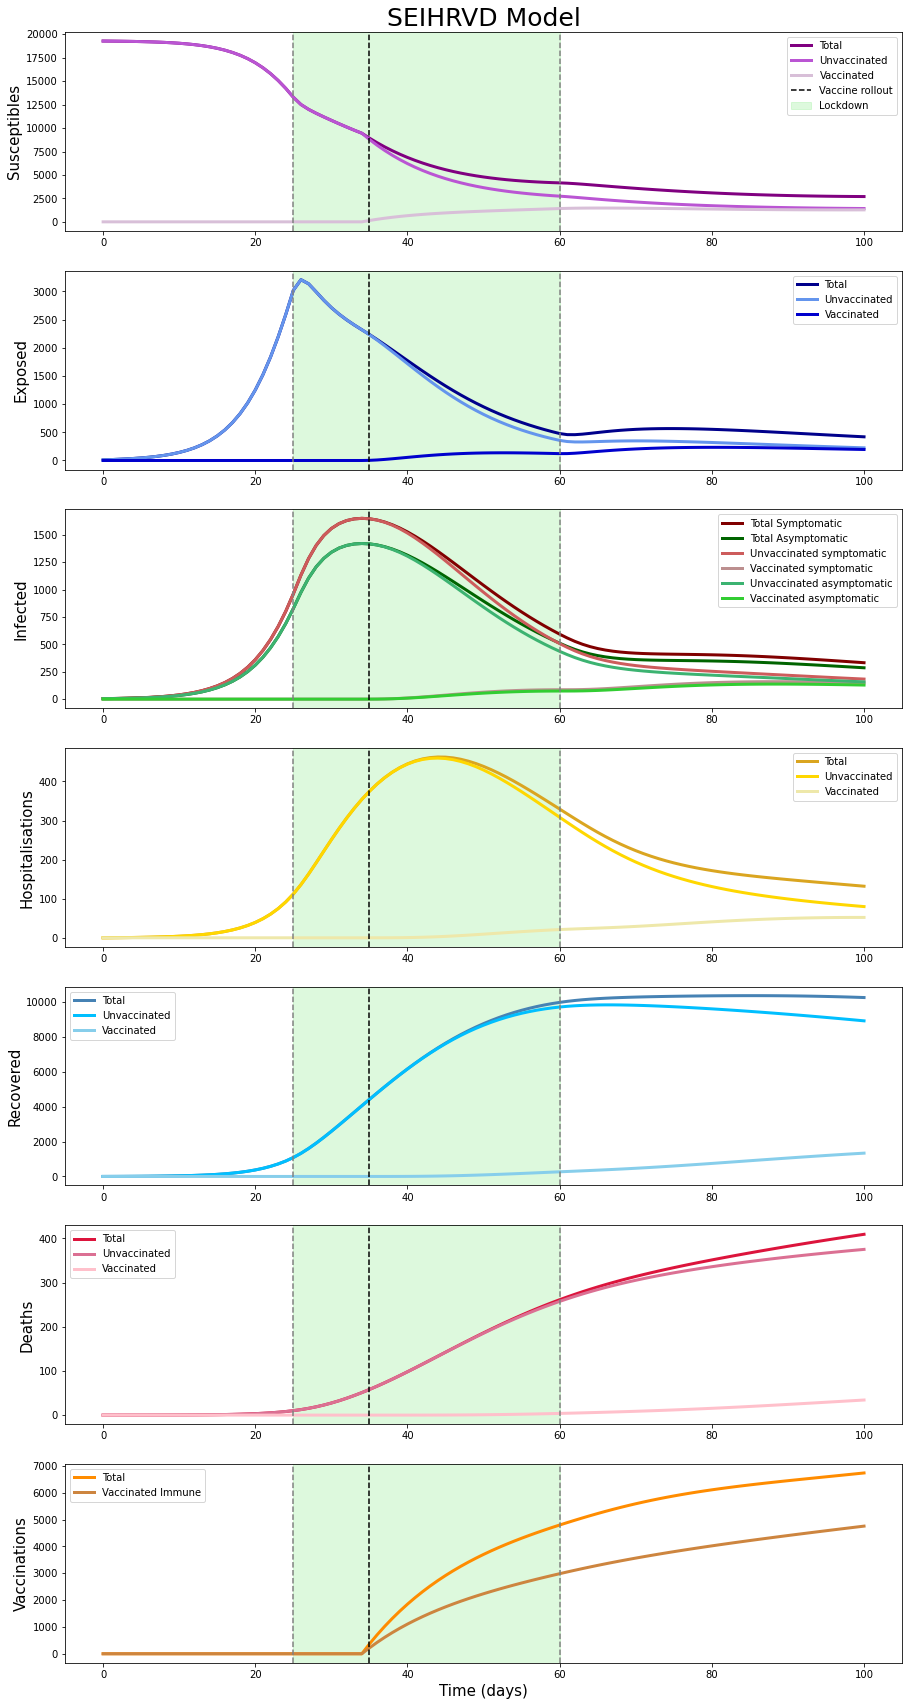

In [70]:
# Intervention measure parameters
vaccineStart = 35
eta = 0.6
lockdownStart = 25
lockdownEnd = 60

sim = SEIHRVDsim(elderlyAgeGrp, vaccineStart, eta, lockdownStart, lockdownEnd)
sim.ODEsolver()
sim.ModelPlotting()